<a href="https://colab.research.google.com/github/Suharyanto-env/Sampah-Dumai/blob/main/Peta0_Indeks_Sampah_Kec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================================
#    STRUKTUR PENGELOLAAN SAMPAH KECAMATAN DI KOTA DUMAI
# ==========================================================================

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# unduh dokumen dari google sheet
#CATATAN : 1) STATUS FILE : share everyone   2) Nama file yg dipakai ID nya (tengok di kolom link https nya)

url = "https://docs.google.com/spreadsheets/d/128izVArqpYAnbYxUyI2nS431qNAOxNpPj6gfYa68ix8/export?format=csv"

df = pd.read_csv(url)

df

,No,kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,%RT,RT,Terolah,Reduksi,Liar,Hidden,Leaked,%Leaked
0,1,DumaiTimur,67000,0.7,46900,20%,9380,300,0.01,469,769,500,1000,35251,36251,77.29
1,2,DumaiBarat,44200,0.7,30940,40%,12376,750,0.15,4641,5391,2000,1600,9573,11173,36.11
2,3,DumaiKota,40900,0.7,28630,60%,17178,900,0.20,5726,6626,3000,750,1076,1826,6.38
3,4,BukitKapur,49000,0.7,34300,50%,17150,1000,0.25,8575,9575,4000,2500,1075,3575,10.42
4,5,MedangKampai,14500,0.7,10150,0%,0,1500,0.10,1015,2515,2000,3000,2635,5635,55.52
5,6,SungaiSembilan,38000,0.7,26600,0%,0,5000,0.30,7980,12980,5000,2000,6620,8620,32.41
6,7,DumaiSelatan,54200,0.7,37940,0%,0,7500,0.50,18970,26470,5500,3000,2970,5970,15.74


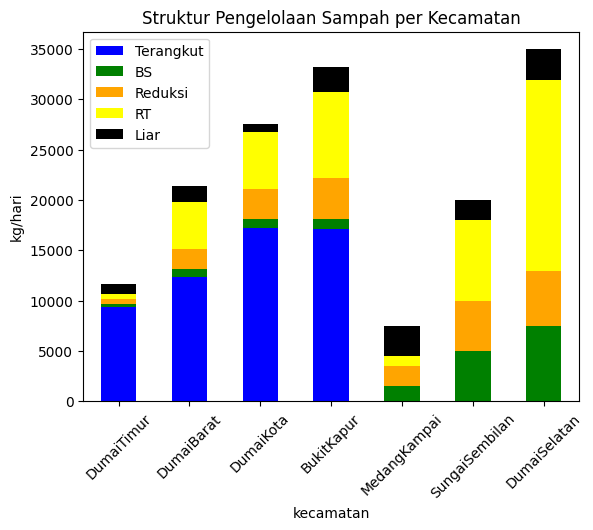

In [ ]:
# pembuatan diagram batang struktur pengelolaan sampah per kecamatan
# ========================================================================

df_plot = df.set_index("kecamatan")[["Terangkut","BS","Reduksi","RT","Liar"]]
#CATATAN :
#   Terangkut = pelayanan armada pemkot
#   BS = Bank Sampah, TPST, TPS3R
#   RT = pengurangan sampah di RT (asumsi)
#   Reduksi = Lapak, Kawasan dll
#   Liar = TPS Liar, sampah menumpuk tanpa izin
# (tabel belum termasuk sampah hidden)

df_plot.plot(kind="bar", stacked=True,
             color={"Terangkut":"blue",
             "BS":"green",
             "Reduksi":"orange",
             "RT":"yellow",
             "Liar":"black"})

plt.title("Struktur Pengelolaan Sampah per Kecamatan")

plt.ylabel("kg/hari")

plt.xticks(rotation=45)

plt.show()

# 📊 WLSRI (Waste Local Service Resilience Index)

## 1. Definisi

**WLSRI (Waste Local Service Resilience Index)** adalah indeks komposit yang digunakan untuk menilai tingkat **kemandirian dan ketahanan sistem pengelolaan sampah** di suatu wilayah (misalnya kecamatan).

Indeks ini menggambarkan kemampuan wilayah dalam:

* menangani sampah yang dihasilkan,
* mengurangi ketergantungan pada sistem eksternal,
* meminimalkan kebocoran sampah ke lingkungan.

---

## 2. Komponen Penyusun

WLSRI disusun dari 4 komponen utama:

### 1. SPI (Service Performance Index)

Menggambarkan tingkat pelayanan pengangkutan sampah.

[
SPI = {Terangkut} / {Timbulan}
]

---

### 2. Reduksi Ratio

Menggambarkan kemampuan pengurangan sampah dari sumber (misalnya bank sampah, komposting).

[
Reduksi Ratio = {Reduksi} / {Timbulan}
]

---

### 3. Terolah Ratio

Menggambarkan kemampuan pengolahan sampah di dalam sistem.

[
Terolah Ratio = {Terolah} / {Timbulan}
]

---

### 4. Leakage Index

Menggambarkan tingkat kebocoran sampah ke lingkungan.

[
Leakage Index = {un-Manage} / {Timbulan}
]

dimana:
[
un-Manage = Liar + Hidden
]

---

## 3. Rumus WLSRI

[
WLSRI = (0.4 * SPI) + (0.2 * Reduksi Ratio) + (0.2 * Terolah Ratio) - (0.2 * Leakage Index)
]

---

## 4. Interpretasi Nilai

| Nilai WLSRI | Interpretasi                       |
| ----------- | ---------------------------------- |
| > 0.70      | Sistem sangat mandiri dan efektif  |
| 0.50 – 0.70 | Sistem cukup baik                  |
| 0.30 – 0.50 | Sistem sedang, perlu intervensi    |
| < 0.30      | Sistem lemah, prioritas penanganan |

---

## 5. Makna Analitis

WLSRI memberikan gambaran keseimbangan antara:

✔ **Kinerja pelayanan (SPI)**
✔ **Upaya pengurangan (Reduksi)**
✔ **Kapasitas pengolahan (Terolah)**
❌ **Kebocoran sistem (Leakage)**

Sehingga indeks ini dapat digunakan untuk:

* menentukan prioritas intervensi kebijakan,
* membandingkan kinerja antar kecamatan,
* mengidentifikasi titik lemah sistem pengelolaan sampah.

---

## 6. Catatan Penting

* Bobot (0.4, 0.2, 0.2, 0.2) dapat disesuaikan dengan kebijakan daerah.
* WLSRI bersifat **komparatif**, sehingga lebih kuat digunakan untuk perbandingan antar wilayah.
* Akurasi indeks sangat bergantung pada kualitas data timbulan dan pengelolaan.

---


In [ ]:
# Nilai WRSRI
# ====================================================================
# perhitungan nilai SPI, Reduksi Ratio, Terolah Ratio, Leakage Index => nilai WLSRI

df['SPI'] = df['Terangkut'] / df['Timbulan']
df['Reduksi_Ratio'] = df['Reduksi'] / df['Timbulan']
df['Terolah_Ratio'] = df['Terolah'] / df['Timbulan']

df['un-Manage'] = df['Timbulan'] - (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Leakage_Index'] = df['un-Manage'] / df['Timbulan']

df['WLSRI'] = (
    0.4 * df['SPI'] +
    0.2 * df['Reduksi_Ratio'] +
    0.2 * df['Terolah_Ratio'] -
    0.2 * df['Leakage_Index']
)

df = df.sort_values(by='WLSRI', ascending=False)

df

,No,kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,%RT,RT,...,Liar,Hidden,Leaked,%Leaked,SPI,Reduksi_Ratio,Terolah_Ratio,un-Manage,Leakage_Index,WLSRI
2,3,DumaiKota,40900,0.7,28630,60%,17178,900,0.20,5726,...,750,1076,1826,6.38,0.6,0.104785,0.231436,1826,0.063779,0.294488
3,4,BukitKapur,49000,0.7,34300,50%,17150,1000,0.25,8575,...,2500,1075,3575,10.42,0.5,0.116618,0.279155,3575,0.104227,0.258309
6,7,DumaiSelatan,54200,0.7,37940,0%,0,7500,0.50,18970,...,3000,2970,5970,15.74,0.0,0.144966,0.697681,5970,0.157354,0.137059
1,2,DumaiBarat,44200,0.7,30940,40%,12376,750,0.15,4641,...,1600,9573,11173,36.11,0.4,0.064641,0.174240,11173,0.361118,0.135553
5,6,SungaiSembilan,38000,0.7,26600,0%,0,5000,0.30,7980,...,2000,6620,8620,32.41,0.0,0.187970,0.487970,8620,0.324060,0.070376
4,5,MedangKampai,14500,0.7,10150,0%,0,1500,0.10,1015,...,3000,2635,5635,55.52,0.0,0.197044,0.247783,5635,0.555172,-0.022069
0,1,DumaiTimur,67000,0.7,46900,20%,9380,300,0.01,469,...,1000,35251,36251,77.29,0.2,0.010661,0.016397,36251,0.772942,-0.069177


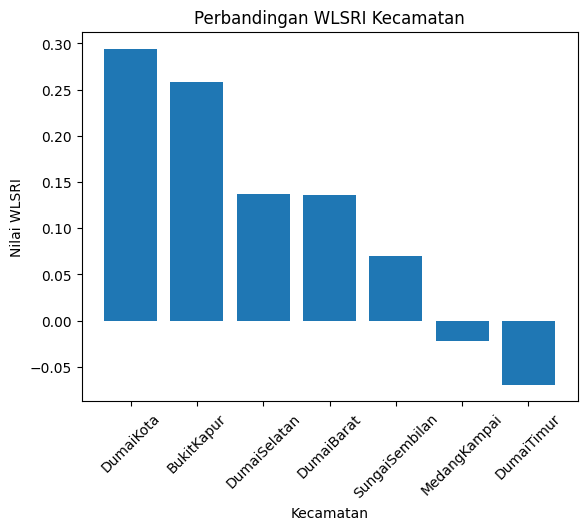

In [ ]:
# Diagram batang perbandingan WLSRI antar kecamatan

plt.figure()
plt.bar(df['kecamatan'], df['WLSRI'])
plt.xticks(rotation=45)
plt.title("Perbandingan WLSRI Kecamatan")
plt.xlabel("Kecamatan")
plt.ylabel("Nilai WLSRI")
plt.show()

In [ ]:
# Ranking WLSRI
df['Ranking'] = df['WLSRI'].rank(ascending=False, method='min')

# Urutkan
df = df.sort_values(by='WLSRI', ascending=False)

# Tampilkan inti perbandingan
df[['kecamatan','WLSRI','Ranking']]

,kecamatan,WLSRI,Ranking
2,DumaiKota,0.294488,1.0
3,BukitKapur,0.258309,2.0
6,DumaiSelatan,0.137059,3.0
1,DumaiBarat,0.135553,4.0
5,SungaiSembilan,0.070376,5.0
4,MedangKampai,-0.022069,6.0
0,DumaiTimur,-0.069177,7.0


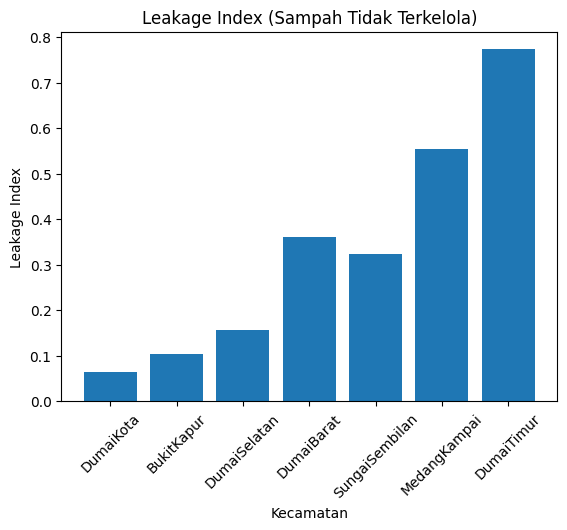

In [ ]:
# Diagram Batang Leakage Index (sampah tidak terkelola)

plt.figure()
plt.bar(df['kecamatan'], df['Leakage_Index'])
plt.xticks(rotation=45)
plt.title("Leakage Index (Sampah Tidak Terkelola)")
plt.xlabel("Kecamatan")
plt.ylabel("Leakage Index")
plt.show()

In [ ]:
# Tabel Nilai WLSRI dan Kemandirian_Index
# =================================================================

df['Indek_Pengurangan'] = (
    df['Reduksi'] + df['Terolah']
) / df['Timbulan']

df[["kecamatan","WLSRI","Indek_Pengurangan"]]

,kecamatan,WLSRI,Indek_Pengurangan
2,DumaiKota,0.294488,0.336221
3,BukitKapur,0.258309,0.395773
6,DumaiSelatan,0.137059,0.842646
1,DumaiBarat,0.135553,0.238882
5,SungaiSembilan,0.070376,0.675940
4,MedangKampai,-0.022069,0.444828
0,DumaiTimur,-0.069177,0.027058


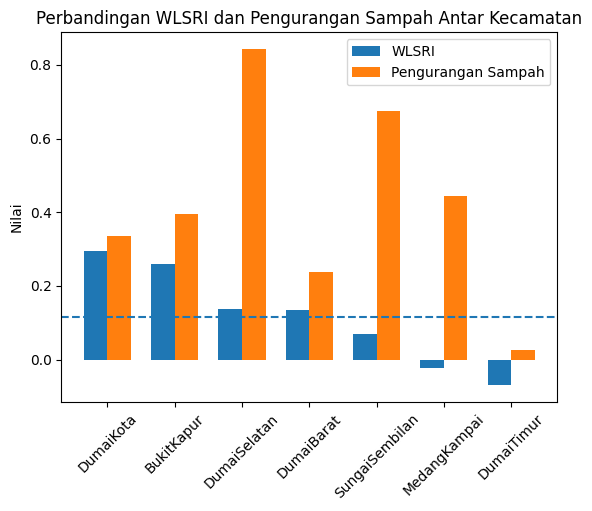

In [ ]:
# Diagram Batang Perbandingan WLSRI dan Kemandirian Index

import numpy as np

# pastikan sudah ada kolom ini
df['Indek_Pengurangan'] = (df['Reduksi'] + df['Terolah']) / df['Timbulan']

# urutkan
df = df.sort_values(by='WLSRI', ascending=False)

x = np.arange(len(df))
width = 0.35

plt.figure()

plt.bar(x - width/2, df['WLSRI'], width, label='WLSRI')
plt.bar(x + width/2, df['Indek_Pengurangan'], width, label='Pengurangan Sampah')

plt.xticks(x, df['kecamatan'], rotation=45)
plt.ylabel("Nilai")
plt.title("Perbandingan WLSRI dan Pengurangan Sampah Antar Kecamatan")

plt.axhline(df['WLSRI'].mean(), linestyle='--')

plt.legend()
plt.show()

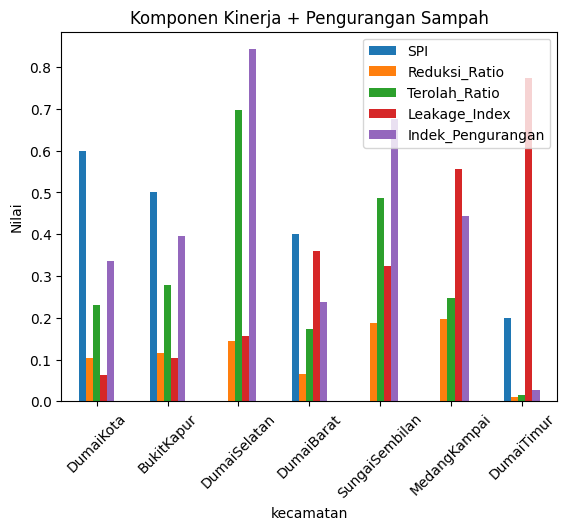

In [ ]:
# Diagram Batang Struktur dan Kemandirian Pengelolaan Sampah

df_plot = df.set_index('kecamatan')[[
    'SPI', 'Reduksi_Ratio', 'Terolah_Ratio',
    'Leakage_Index', 'Indek_Pengurangan'
]]

df_plot.plot(kind='bar')
plt.title("Komponen Kinerja + Pengurangan Sampah")
plt.xticks(rotation=45)
plt.ylabel("Nilai")
plt.show()

In [ ]:
# ANALISIS
# ===========================================================================

# Validasi dasar
df['Total_Terkelola'] = (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Tidak_Terkelola'] = df['Timbulan'] - df['Total_Terkelola']

def klasifikasi_kebocoran(row):

    if row['Timbulan'] == 0:
        return "DATA TIDAK VALID"

    rasio = row['Tidak_Terkelola'] / row['Timbulan']

    df['%Leakage'] = df['Tidak_Terkelola'] / df['Timbulan'] * 100

    if rasio > 0.7:
        return "KRISIS"
    elif rasio > 0.5:
        return "TINGGI"
    elif rasio > 0.3:
        return "SEDANG"
    else:
        return "RENDAH"

In [ ]:
df['Kategori_Kebocoran'] = df.apply(klasifikasi_kebocoran, axis=1)

In [ ]:
df[['kecamatan','Tidak_Terkelola','Timbulan','%Leakage','Kategori_Kebocoran']]

,kecamatan,Tidak_Terkelola,Timbulan,%Leakage,Kategori_Kebocoran
2,DumaiKota,1826,28630,6.377925,RENDAH
3,BukitKapur,3575,34300,10.422741,RENDAH
6,DumaiSelatan,5970,37940,15.735372,RENDAH
1,DumaiBarat,11173,30940,36.111829,SEDANG
5,SungaiSembilan,8620,26600,32.406015,SEDANG
4,MedangKampai,5635,10150,55.517241,TINGGI
0,DumaiTimur,36251,46900,77.294243,KRISIS


KRISIS  → merah
TINGGI  → oranye
SEDANG  → kuning
RENDAH  → hijau

In [ ]:
# PENTING

import geopandas as gpd
import pandas as pd
import requests
import zipfile
import os

In [ ]:
# Download GADM Indonesia (level kecamatan)
# url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IDN_shp.zip"

# r = requests.get(url)
# with open("gadm.zip", "wb") as f:
#    f.write(r.content)

# Extract
# with zipfile.ZipFile("gadm.zip", 'r') as zip_ref:
#    zip_ref.extractall("gadm_data")

1. import
2. baca shapefile
3. filter Dumai
4. rename kolom
5. merge data
6. klasifikasi
7. peta

In [ ]:
# 1. BACA SHAPEFILE
# =======================================================================================================

# Level 3 = kecamatan
gdf = gpd.read_file("gadm_data/gadm41_IDN_3.shp")

# Filter Kota Dumai
dumai = gdf[gdf["NAME_2"] == "Dumai"]

# Pilih & rename kolom
dumai = dumai[["NAME_3", "geometry"]]
dumai = dumai.rename(columns={"NAME_3": "nama_kecamatan"})

In [ ]:
# os.makedirs("output", exist_ok=True)

# dumai.to_file("output/kecamatan_dumai.shp")

In [ ]:
# dumai.to_file("output/kecamatan_dumai.geojson", driver="GeoJSON")

In [ ]:
# from google.colab import files

# zip semua output
# !zip -r hasil_dumai.zip output

# files.download("hasil_dumai.zip")

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
# !pip install geopandas folium openpyxl

In [ ]:
# gdf = gdf.merge(df, left_on="nama_kecam",right_on="kecamatan")

In [ ]:
# print(gdf.head())
# print(gdf.columns)
# print(type(gdf))

In [ ]:
# print(len(gdf))   # sebelum merge
# print(len(df))

In [ ]:
# cek isi folder saja

# import os
# os.listdir()

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "nama_kecamatan": [
        "Dumai Kota","Dumai Timur","Dumai Selatan",
        "Dumai Barat","Bukit Kapur","Medang Kampai","Sungai Sembilan"
    ],
    "persen_kebocoran": [75,60,45,30,20,55,80]
})

KENAPA TERJADI?

👉 sebelumnya ada 2 versi:

shapefile lama → nama_kecam
shapefile GADM → nama_kecamatan

👉 sekarang Bapak sudah pakai GADM
👉 tapi masih pakai nama lama

🎯 CARA CEK CEPAT (BIAR TIDAK SALAH LAGI)
print(gdf.columns)

👉 lihat nama kolom asli
👉 pakai persis itu

In [ ]:
print(gdf.columns)
print(df.columns)

Index(['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2',
       'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3',
       'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry'],
      dtype='object')
Index(['nama_kecamatan', 'persen_kebocoran'], dtype='object')


In [ ]:
#  2. DATA +  MERGE
# ============================================================================================

# filter Dumai + rename
gdf = gdf[gdf["NAME_2"] == "Dumai"]
gdf = gdf[["NAME_3", "geometry"]]
gdf = gdf.rename(columns={"NAME_3": "nama_kecamatan"})

# normalisasi  -   kalo pake "nama_kecam"  =>  error
gdf["nama_kecamatan"] = gdf["nama_kecamatan"].str.strip().str.lower()
df["nama_kecamatan"] = df["nama_kecamatan"].str.strip().str.lower()

# merge
gdf = gdf.merge(df, on="nama_kecamatan")

print(len(gdf))  # harus 7

5


In [ ]:
# 3. KATEGORI
# ===============================================================================================

def klasifikasi(x):
    if x > 70:
        return "KRISIS"
    elif x > 50:
        return "TINGGI"
    elif x > 30:
        return "SEDANG"
    else:
        return "RENDAH"

gdf["kategori"] = gdf["persen_kebocoran"].apply(klasifikasi)

In [ ]:
import geopandas as gpd
import requests
import zipfile

# download GADM
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IDN_shp.zip"
r = requests.get(url)

with open("gadm.zip", "wb") as f:
    f.write(r.content)

# extract
with zipfile.ZipFile("gadm.zip", 'r') as zip_ref:
    zip_ref.extractall("gadm")

# baca kecamatan
gdf = gpd.read_file("gadm/gadm41_IDN_3.shp")

# filter Dumai
gdf = gdf[gdf["NAME_2"] == "Dumai"]

# ambil kolom penting
gdf = gdf[["NAME_3", "geometry"]]
gdf = gdf.rename(columns={"NAME_3": "nama_kecamatan"})

print(len(gdf))
gdf.head()

5


,nama_kecamatan,geometry
4769,Bukit Kapur,"POLYGON ((101.51488 1.48169, 101.5132 1.48171,..."
4770,Dumai Barat,"POLYGON ((101.37273 1.60609, 101.37228 1.60591..."
4771,Dumai Timur,"POLYGON ((101.41179 1.60181, 101.41528 1.6028,..."
4772,Medang Kampai,"POLYGON ((101.51763 1.48456, 101.51744 1.4844,..."
4773,Sungai Sembilan,"POLYGON ((101.3336 1.61594, 101.33317 1.61575,..."


In [ ]:
# inti analisis

df["nama_kecamatan"] = df["nama_kecamatan"].str.lower()
gdf["nama_kecamatan"] = gdf["nama_kecamatan"].str.lower()

gdf = gdf.merge(df, on="nama_kecamatan")

In [ ]:
# setelah merge
def klasifikasi(x):
    if x > 70:
        return "KRISIS"
    elif x > 50:
        return "TINGGI"
    elif x > 30:
        return "SEDANG"
    else:
        return "RENDAH"

gdf["kategori"] = gdf["persen_kebocoran"].apply(klasifikasi)

[ CELL 1 ]
ambil shapefile

[ CELL 2 ]
merge + kategori   ✅ (yang sekarang terlihat di screenshot)

👉 TAMBAHKAN DI SINI

[ CELL 3 ]
peta (kode di atas)

In [ ]:
#  4. PETA
# ===========================================================================================================

import folium

def warna(kat):
    if kat == "KRISIS":
        return "red"
    elif kat == "TINGGI":
        return "orange"
    elif kat == "SEDANG":
        return "yellow"
    else:
        return "green"

center = gdf.geometry.centroid.iloc[0]

m = folium.Map(location=[center.y, center.x], zoom_start=11)

folium.GeoJson(
    gdf,
    style_function=lambda x: {
        'fillColor': warna(x['properties']['kategori']),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["nama_kecamatan", "kategori"],
        aliases=["Kecamatan:", "Status:"]
    )
).add_to(m)

m

/tmp/ipykernel_19225/1244842603.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = gdf.geometry.centroid.iloc[0]
